In [1]:
import numpy as np

In [2]:
# Data for Regression
x = np.array([[1],[2],[3],[4],[5]])
y = np.array([10,14,21,25,32])

In [3]:
# Data for Classification
a = np.array([
    [1],[2],[3],[4],[5],
    [6],[7],[8],[9],[10],
    [11],[12],[13],[14],[15],
    [16],[17],[18],[19],[20]
])
b = np.array([
    0,0,0,0,0,
    0,0,0,1,1,
    1,1,1,1,1,
    1,1,1,1,1
])

# **ALGORITHMS**

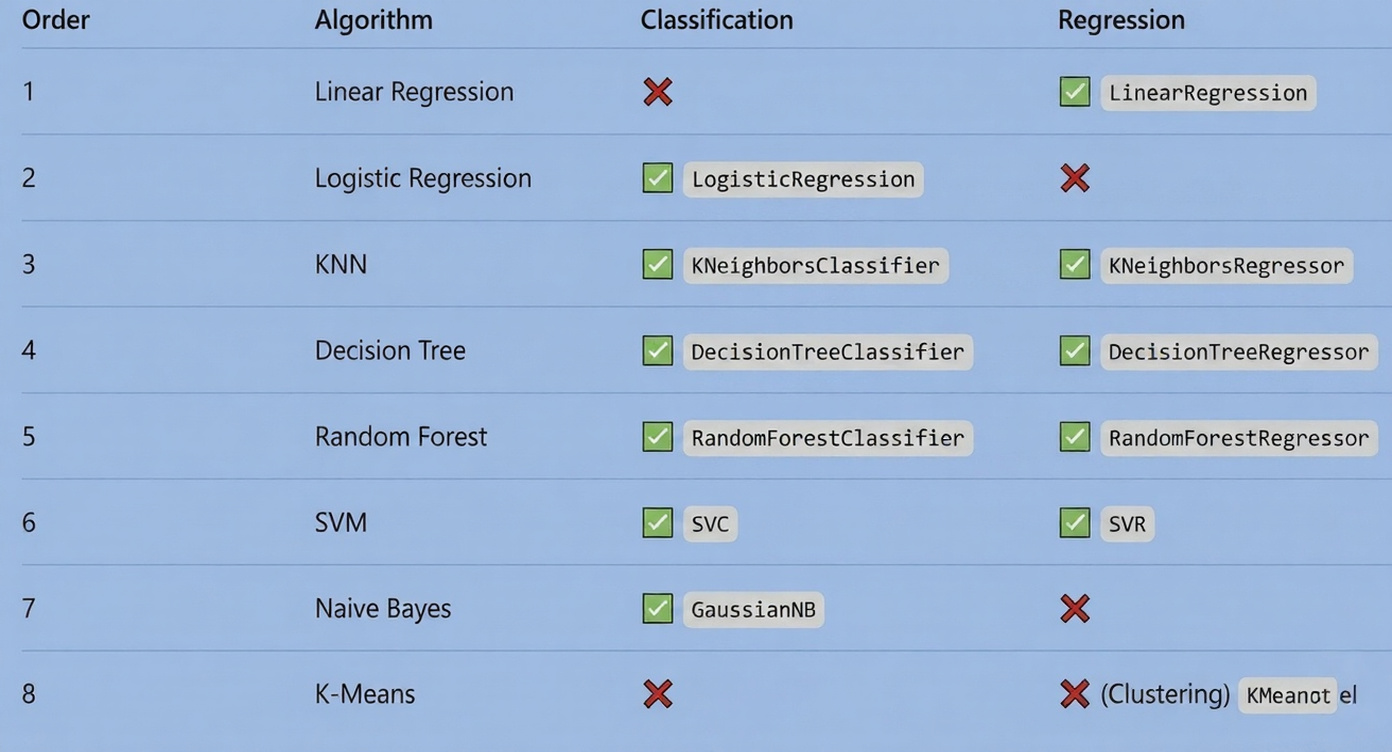

## **1) Linear Regression**
### A supervised learning algorithm used to predict continuous numerical values by fitting the best straight line to the data.


> Formula -> y=mx+c

> where y=output, x=input,

> m=slope(how much y changes wrto x), c=intercept(value of y when x=0)

##Goal of Linear Regression

###The model keeps changing:

###m (slope) and b (intercept)

###until the total error becomes as small as possible.
###where total error = actual-predicted

###  Think: Try a line -> Calculate Error -> Adjust Line -> Calculate Error -> Adjust Again -> Find Best Line





In [4]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x,y)
prediction = model.predict([[6]])
print(model.coef_) # slope
print(model.intercept_) # intercept
print(prediction)

[5.5]
3.8999999999999986
[36.9]


## **Multiple Linear Regression**
### Multiple Linear Regression predicts one target value using multiple input features.
### Formula : y = b + m1​x1​ + m2​x2​ + m3​x3​
### where x1,x2,x3 are input features ( multiple )
### m1 is slope of x1 and m2 -> x2, m3 -> x3
### b is intercept of y ( value of y when {x1,x2,x3} = 0 )


In [5]:
from sklearn.linear_model import LinearRegression
m = np.array([[1500,3,7.5],[2200,4,8.8],[1200,2,6.2]]) # [size,numof_bedrooms,location_score]
n = np.array([315000,480000,210000]) # [House price]
model = LinearRegression()
model.fit(m,n)
prediction = model.predict([[2800,5,9.5]])
print(prediction)

[612602.23048327]


## **2) Logistic Regression**
### A supervised learning algorithm used for classification problems, especially binary classification.
### Why called Logistic Regression? Because it uses a mathematical function called the Sigmoid Function to convert any number into probability ( despite name as regression, it is mainly used for classification )
### Linear Regression predicts numbers while Logistic Regression predicts Categories like spam/notspam, Pass/Fail
### output of logistic regression : Like probability, example : 0.95 means 95% chance of pass --> Probability ≥ 0.5 means Class = 1, Probability < 0.5 means Class = 0
## Important Functions :
###model.predict() -> predicts class
###model.predict_proba() -> predict probabilty (o/p : [[probability that class0  probability that class1]])

In [6]:
from sklearn.linear_model import LogisticRegression
import numpy as np
model = LogisticRegression()
model.fit(a,b)
prediction = model.predict([[21]])
print(prediction)
probability_prediction = model.predict_proba([[21]])
print(probability_prediction)

[1]
[[3.28041570e-07 9.99999672e-01]]


## **3) K - Nearest Neighbors ( KNN )**

### K = Number of Neighbors

## Comparison
### KNeighborsRegressor -> Find K Nearest Neighbors -> Take Average -> Predict Number
### KNeighborsClassifier -> Find K Nearest Neighbors -> Majority Vote -> Predict Class

### n_neighbors = K

### fit() → Store Data

### predict() → Find Neighbors + Vote/predictno


In [7]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors = 3)
model.fit(a,b)
prediction = model.predict([[21]])
print(prediction)

[1]


In [8]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors = 3)
model.fit(x,y)
prediction = model.predict([[6]])
print(prediction)

[26.]


### K = Number of Neighbors

### K Too Small --> Overfitting

### K Too Large --> Underfitting

### Common Values:
### K = 3, 5, 7

### Prefer Odd K --> To Avoid Ties like 2Pass,2Fail ( when even no is choosen, tie happens)

### Best K --> Found using model evaluation.


---



### KNN uses Distance to find nearest neighbors.

### Most Common:
### Euclidean Distance

### Steps:
### 1. Calculate distance
### 2. Sort distances
### 3. Select K nearest neighbors
### 4. Majority vote/average
### 5. Predict class/predict number

### Smaller Distance --> Closer Neighbor

## **4) Decision Trees**
### Predicts using questions/rules.

## Structure:

### Root Node -> Branches -> Leaf Nodes

### Root Node = First Question
### Branch = Path
### Leaf Node = Final Prediction

## Advantages:
### - Easy to understand
### - No scaling required

## Disadvantages:
### - Overfitting

In [9]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier() # default uses gini index
# model = DecisionTreeClassifier(criterion='entropy') # criterion prarameter
model.fit(a,b)
prediction = model.predict([[21]])
print(prediction)
print(model.feature_importances_) # tree tells which features were mostly used

[1]
[1.]


In [10]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(x,y)
prediction = model.predict([[6]])
print(prediction)
print(model.feature_importances_)

[32.]
[1.]


## Decision Tree chooses the best split using:

### 1. Gini Index
### 2. Entropy

## Entropy:
### Measures Disorder

## Gini:
### Measures Impurity

### Pure Groups -> Low Entropy, Low Gini

### Mixed Groups -> High Entropy, High Gini

###Decision Tree selects the split with the lowest gini(default and fast in scikitlearn)/entropy(alternative).

## **5) Random Forest**
### A Random Forest is a collection of many Decision Trees.
### Many Decision Trees -> Voting (Classification), Averaging (Regression)

## Advantages:
### High Accuracy, Less Overfitting, Feature Importance

## Important Parameter:
### n_estimators ( by default without n_estimators parameter, DecisionTreeclassifier() creates 100 trees only)
### n_estimators=100 -> 100 Trees

### Decision Tree : One Tree
### Random Forest : Many Trees

In [11]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
# model = RandomForestClassifier(n_estimators=100) # meaning-100 decision trees
model.fit(a,b)
prediction = model.predict([[21]])
print(prediction)
print(model.feature_importances_)

[1]
[1.]


In [12]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(x,y)
prediction = model.predict([[6]])
print(prediction)
print(model.feature_importances_)

[29.73]
[1.]


## Random Forest creates different trees using:

### 1. Bootstrap Sampling - Different rows

### 2. Random Feature Selection - Different features

### Different Trees -> Voting  -> Less Overfitting -> Better Accuracy

## **6) Support Vector Machine ( SVM )**


### SVM = Support Vector Machine -> SVC and SVR

### Hyperplane -> Separating Line

### Margin -> Distance from Hyperplane

### Support Vectors -> Closest Data Points

## Goal:
### Find Hyperplane with Maximum Margin

## Advantages:
### - High Accuracy
### - Good for Classification ( SVM became famous for SVC )

In [13]:
from sklearn.svm import SVC
model = SVC()
model.fit(a,b)
prediction = model.predict([[21]])
print(prediction)

[1]


In [14]:
from sklearn.svm import SVR
model = SVR()
model.fit(x,y)
prediction = model.predict([[7]])
print(prediction)

[21.14644054]


## Important parameters : C and kernel

## C :
### High C → Overfitting Risk
### Low C → Simpler Model

## kernel :
### Linear Data -> Use Linear Kernel
### Non-Linear Data -> Use Kernel Trick

### Common Kernels:
### 1. linear
### 2. rbf (default)
### 3. poly

### Kernel Trick : A technique used by SVM to handle non-linear data by transforming it into a higher-dimensional space where it can be separated.

In [15]:
from sklearn.svm import SVR
model = SVR(C=100,kernel='linear') # parameters - C and kernel
model.fit(x,y)
prediction = model.predict([[7]])
print(prediction)

[42.9]


## **7) Naive Bayes**
### A supervised classification algorithm based on probability and Bayes Theorem.
### Why is it called Naive? - Because it assumes all features are independent.
### Prediction: Choose class with highest probability

## There are several Naive Bayes variants:
### GaussianNB ( most common )
### MultinomialNB
### BernoulliNB

## Advantages:
### - Fast
### - Good for text classification

### Type: Supervised, Classification Only

In [16]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(a,b)
prediction = model.predict([[21]])
print(prediction)

[1]


## Bayes Theorem

### Old Belief + New Evidence -> Updated Belief

## Naive Bayes:
### 1. Calculate probability of each class
### 2. Choose highest probability class

## Uses:
### Spam Detection
### Text Classification
### Sentiment Analysis

### Higher Probability -> Predicted Class

## **8) K-Means**
### Type: Unsupervised Learning

### Purpose: Clustering

### K -> Number of Clusters

### Centroid -> Center of Cluster

### Centroid Update -> Average (Mean) of all points in that cluster

## Steps:
### 1. Choose K
### 2. Place Centroids
### 3. Assign Points to nearest centroid
### 4. Calculate new centroid (Mean)
### 5. Move centroid
### 6. Repeat until centroids stop moving

###Scikit-Learn: KMeans(n_clusters=K)

### Important: labels_, cluster_centers_

In [17]:
from sklearn.cluster import KMeans
data = np.array([[1],[2],[3],[8],[9],[10]])
model = KMeans(n_clusters=2)
model.fit(data)
clusters = model.predict(data)
print(clusters)
print(model.labels_) # cluster labels, meaning : cluster 0 and cluster 1 -> since n_clusters=2
print(model.cluster_centers_) # updated centroids

[1 1 1 0 0 0]
[1 1 1 0 0 0]
[[9.]
 [2.]]


## Elbow Method

### Purpose : Choose Best K

### WCSS -> Within Cluster Sum of Squares

### Lower WCSS -> Better Clusters

## Steps:
### 1. Run K-Means for different K values
### 2. Calculate WCSS
### 3. Plot K vs WCSS
### 4. Find Elbow Point
### 5. Choose that K

### Scikit-Learn : model.inertia_

### inertia_ = WCSS

In [18]:
from sklearn.cluster import KMeans
wcss = []
for k in range(1,7):
  model = KMeans(n_clusters=k)
  model.fit(data)
  wcss.append(model.inertia_)
print(wcss)

[77.5, 4.0, 2.5, 2.0, 0.5, 0.0]


### WCSS always decreases as K increases.

### Choose K at the Elbow Point ( Huge Drop ), not the smallest WCSS.

### Here the elbow point is at k=2 , where it dropped from 77.5 to 4.0